In [146]:
#%matplotlib ipympl
%matplotlib inline
 
import numpy as np
from functions import *
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition._nmf import _initialize_nmf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from scipy import signal
from gudhi.point_cloud.timedelay import TimeDelayEmbedding
from torch_topological.nn import VietorisRipsComplex
import torch.optim as optim

#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'
print('Device', device)



def plot_gallery(images, title="", n_col=5, n_row=5, cmap=plt.cm.gray, axs=None):
    if axs is None:
        fig, axs = plt.subplots(n_row, n_col, figsize=(2. * n_col, 2.26 * n_row))
        plt.subplots_adjust(0.01, 0.05, 0.99, 0.93, 0.04, 0.)
        plt.suptitle(title, size=16)

    for i, comp in enumerate(images):
        if n_row != 1:
            ax = axs[i // n_col, i % n_col]
        else:
            ax = axs[i % n_col]

        ax.cla()  # ✅ 기존 선 제거
        ax.plot(comp)
        ax.set_xticks(())
        ax.set_yticks(())

    return axs


def plot_PD(data, n_col=5, n_row=5, M=1, tau=1, axs=None):
    if axs is None:
        fig,axs = plt.subplots(n_row, n_col, figsize=(2. * n_col, 2.26 * n_row))
    for i, comp in enumerate(data):
        embedder = TimeDelayEmbedding(dim=M+1, delay=tau)
        embedded = embedder(comp)
        centered = center_point_cloud(embedded)
        rips_complex = gudhi.RipsComplex(points=centered).create_simplex_tree(max_dimension=2)
        pd = rips_complex.persistence()
        ax = axs[i//n_col,i%n_col]
        ax.clear()
        gudhi.plot_persistence_diagram(pd,axes=ax,legend=False,fontsize=4)
        ax.set_xticks(())
        ax.set_yticks(())



def update_V(X, W, V, k):
    WtW = W.T @ W
    cach = -W.T @ X + WtW @ V
    for i in range(V.shape[0]):
        C = cach[i] - WtW[i, i] * V[i]
        vi = torch.as_tensor(sparse_opt(-C.to('cpu').detach().numpy(), k), device=device)
        cach = cach + torch.outer(WtW[:,i],vi - V[i])
        V[i] = vi
    return V  

def sparse_opt(b, k, epsilon=1e-10):
    if k<=0:
        return(b)
    permutation = np.argsort(b)[::-1]
    a = b[permutation]
    m = len(b)
    x = np.zeros(m, dtype=np.float64)

    y = np.zeros_like(x)
    bot = np.int64(np.ceil(k * k))
    if bot > m or k==1:
        y[permutation[0]]=1
        return y

    a_squared = a**2
    cumsum_a_squared = np.cumsum(a_squared)
    cumsum_a = np.cumsum(a)

    P = np.arange(1, m + 1, dtype=np.float64)
    
    numerator = P * cumsum_a_squared - cumsum_a**2
    denominator = P - k**2
    valid_mask = (denominator > 0) & (numerator > 0)
    #print(numerator,denominator,valid_mask)
    lambda_values = np.zeros_like(P)+epsilon
    mu_values = np.zeros_like(P)+epsilon
    lambda_values[valid_mask] = -np.sqrt(numerator[valid_mask] / denominator[valid_mask])
    mu_values[valid_mask] = -cumsum_a[valid_mask] / P[valid_mask] - k * lambda_values[valid_mask] / P[valid_mask]

    p_candidates = np.arange(np.int64(np.ceil(k * k)), m + 1)
    a_p_candidates = a[p_candidates - 1]
    mu_p_candidates = mu_values[p_candidates - 1]
    valid_p = np.where(a_p_candidates < -mu_p_candidates)[0]
    if len(valid_p)==0:
        pstar = m
    else:
        pstar = p_candidates[valid_p[0]]-1
    lam_pstar = lambda_values[pstar - 1]
    #print( lambda_values,mu_values,pstar)
    mu_pstar = mu_values[pstar - 1]
    x[:pstar] = -(a[:pstar] + mu_pstar) / lam_pstar

    y[permutation] = x
    return y
    
def sparsity_score(v):
    n = len(v.ravel())
    return((np.sqrt(n)-v.abs().sum()/(v**2).sum().sqrt())/(np.sqrt(n)-1))


def sparse_opt_hoyer(x, L1, L2=1, max_iter=100):
    dim = len(x)
    s = x + (L1 - np.sum(x)) / dim
    Z = set()

    for j in range(max_iter):
        # Step 3(a): Compute m_i
        m = np.zeros(dim)
        for i in range(dim):
            if i not in Z:
                m[i] = L1 / (dim - len(Z))

        # Step 3(b): Compute s
        alpha = 0
        sm = s - m
        a = np.sum(sm ** 2)
        b = 2 * np.dot(m, sm)
        c = np.sum(m ** 2) - L2 ** 2

        if a != 0:
            alpha = (-b + np.sqrt(b ** 2 - 4 * a * c)) / (2 * a)
        s = m + alpha * sm

        # Step 3(c): Check non-negativity
        if np.all(s >= 0):
            return s

        # Step 3(d): Update Z and set s_i = 0 for i in Z
        for i in range(dim):
            if s[i] < 0:
                Z.add(i)
                s[i] = 0

        # Step 3(e): Update s_i
        c = (np.sum(s) - L1) / (dim - len(Z))
        for i in range(dim):
            if i not in Z:
                s[i] -= c
    return(np.maximum(s,0))

def svd_initialization(X, n_components):
    """
    Initialize W and H matrices for NMF using SVD.
    
    Parameters:
        X: Input matrix (m x n)
        n_components: Number of components (rank of the factorization)
    
    Returns:
        W: Initialized basis matrix (m x n_components)
        H: Initialized coefficient matrix (n_components x n)
    """
    # Perform Singular Value Decomposition
    U, S, VT = np.linalg.svd(X, full_matrices=False)
    
    # Select top n_components singular values and corresponding vectors
    U = U[:, :n_components]
    S = np.diag(S[:n_components])
    VT = VT[:n_components, :]
    
    # Initialize W and H
    W = np.abs(U @ np.sqrt(S))  # Ensure non-negativity
    V = np.sqrt(S) @ VT  # Ensure non-negativity
    
    return W, V



def center_point_cloud(X):
    one = np.ones(X.shape[1])
    projection = (X @ one) / (one @ one)
    result = (X - np.outer(projection, one)) / np.linalg.norm(X - np.outer(projection, one), axis=1, keepdims=True)
    return result    


class TimeDelayEmbeddingTorch(torch.nn.Module):
    def __init__(self, dim=3, delay=1):
        super(TimeDelayEmbeddingTorch, self).__init__()
        self.dim = dim
        self.delay = delay

    def forward(self, x):
        """
        x: 1D tensor (T,)
        returns: 2D tensor of shape (T - (dim-1)*delay, dim)
        """
        N = x.shape[0]
        d = self.dim
        τ = self.delay

        if N - (d - 1) * τ <= 0:
            raise ValueError("Time series too short for embedding")

        return torch.stack([x[i:N - (d - 1) * τ + i] for i in range(0, d * τ, τ)], dim=1)


def center_point_cloud_torch(X):
    """
    X: (N, D) shaped torch tensor (N points in D dimensions)
    returns: centered & normalized tensor of shape (N, D)
    """
    device = X.device  # GPU 대응
    one = torch.ones(X.shape[1], device=device)  # (D,)
    projection = (X @ one) / (one @ one)  # (N,)
    outer = projection.unsqueeze(1) * one.unsqueeze(0)  # (N, D)
    centered = X - outer
    normalized = centered / torch.norm(centered, dim=1, keepdim=True)
    return normalized        

Device cpu


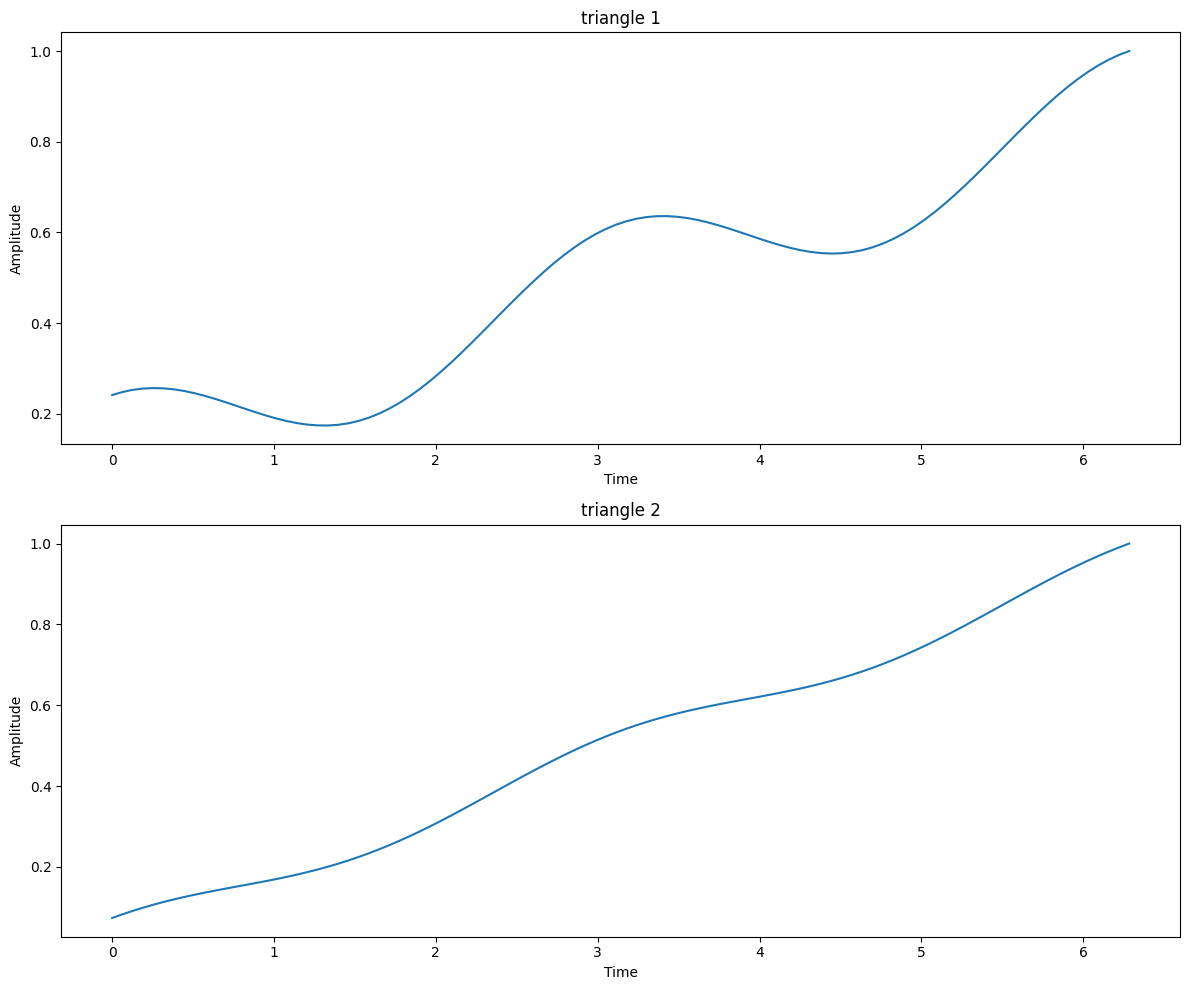

In [202]:
np.random.seed(42)

# 1. 신호 생성 함수들
def generate_signals(t):
    return {
        "cosine_noisy": np.cos(1*t) + 2*np.exp(-t**2) ,
        "cosine_noisy2": np.cos(5*t) + 2*np.exp(-t**2),
        "cosine_noisy3": np.cos(3*t) + np.exp(-t**2),
        "triangle_noisy": np.cos(4*t) + np.exp(-t**2),
    }


def generate_signals(t):
    return {
        "cosine_noisy": t / (4*np.pi)  + np.cos(t),
        "triangle_noisy": t**2 / (4*np.pi)**2 + np.cos(t),
        "triangle_noisy2": t / (4*np.pi)  + np.exp(-t**2),
    }


# def generate_signals(t, n_samples=5, noise_scale=0.01):
#     signals = {}
#     for seed in range(n_samples):
#         np.random.seed(seed)
#         periodic = np.cos(t)
#         non_periodic = (t > 2*np.pi).astype(float)
#         noise = noise_scale * np.random.randn(len(t))
#         mixed = periodic + non_periodic + noise
#         signals[f"signal_seed_{seed}"] = mixed
#     return signals


# def generate_signals(t):
#     signals = {
#         "cosine_noisy": t / (4*np.pi) + np.cos(t),  # ramp + cosine
#         "triangle_noisy": (t**2) / (4*np.pi)**2 + np.cos(t),  # quadratic ramp + cosine
#         "gaussian_cosine": np.exp(-((t - 2*np.pi)**2)) + np.cos(t),  # gaussian bump + cosine
#         "chirp_mix": 0.5 * np.cos(t) + np.sin(t**1.5),  # frequency variation + periodic
#         "cosine_step": (t > 2*np.pi).astype(float) + np.cos(t),  # step + cosine
#         "sawtooth_mix": (t % (2*np.pi)) / (2*np.pi) + np.cos(t),  # modulo ramp + cosine
#     }
#     return signals
    


# def generate_signals(t, n_samples=5, noise_scale=0.1):
#     signals = {}
#     for seed in range(n_samples):
#         np.random.seed(seed)
#         periodic = np.cos(t)
#         non_periodic = t / (4 * np.pi)
#         noise = noise_scale * np.random.randn(len(t))
#         mixed = periodic + non_periodic + noise
#         signals[f"signal_seed_{seed}"] = mixed
#     return signals


def generate_signals(t):
    return {
        "triangle 1": np.cos(2 * t) + t + 1,
        "triangle 2": 0.5*np.cos(2 * t) + 2*t + 0.5,
        # "sawtooth": signal.sawtooth(4  * t) + 0.3 * np.random.randn(len(t)),
        # "noisy_cosine": np.cos(1  * t) + t/(4*np.pi),
        # "noisy_triangle": signal.sawtooth(1 * t, 0.5) + t/(4*np.pi),
        # "double_freq": np.cos(2* t),
    }

t = np.linspace(0, 2*np.pi, 100)
signals = generate_signals(t)

X_list = []
plt.figure(figsize=(12, 10))
for i, (name, sig) in enumerate(signals.items()):
    sig = sig / np.max(sig)
    X_list.append(sig)
    plt.subplot(len(signals), 1, i + 1)
    plt.plot(t, sig)
    plt.title(f"{name}")  # score 없으면 제거 또는 따로 계산해서 넣기
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

(2, 100) (2, 2) (2, 100)


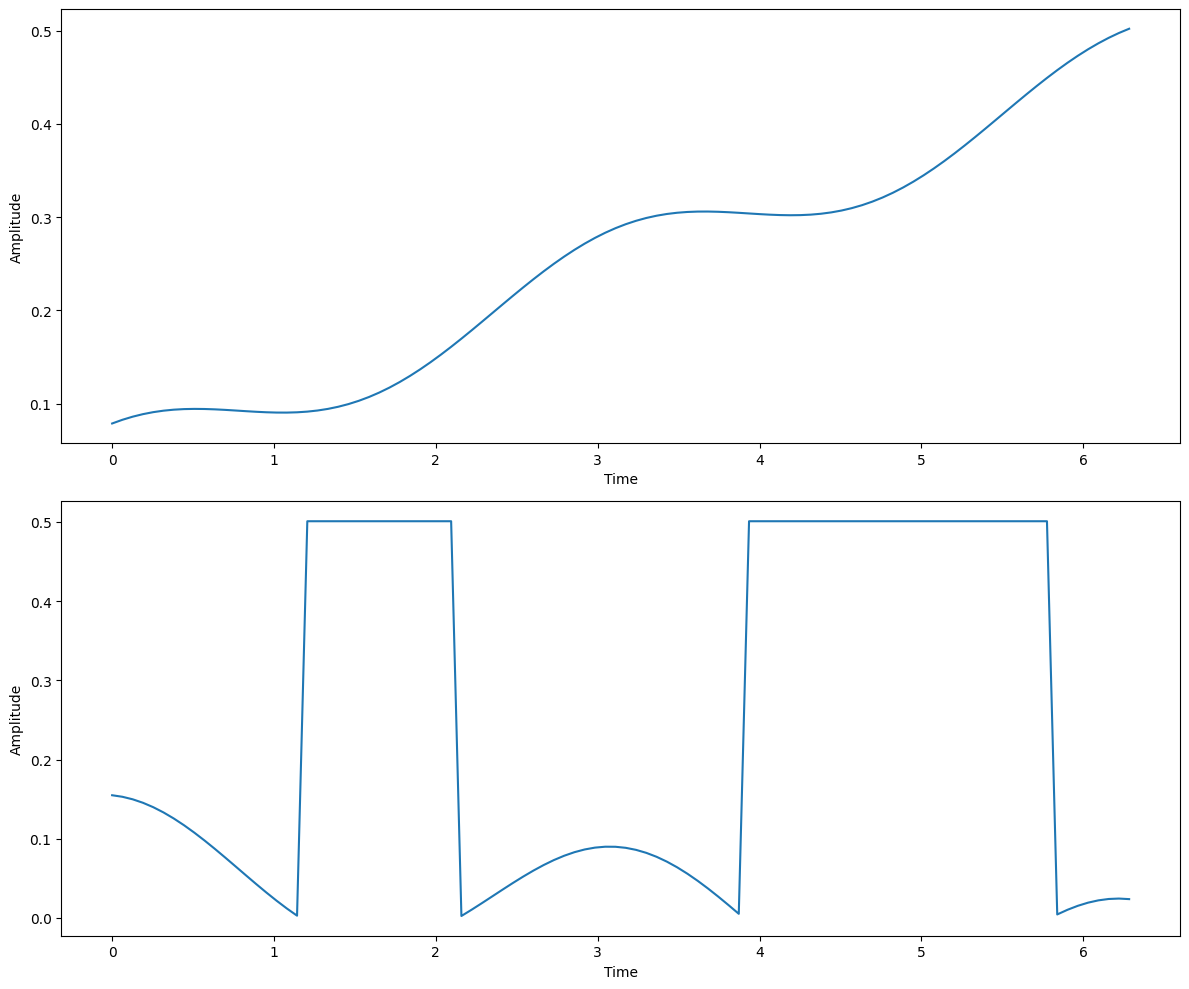

In [203]:
np.random.seed(42)
X = np.array(X_list)
n_components = 2

### Start
n_samples = X.shape[0] # each row represents a sample
data_dims = X.shape[1:]
n_features = X[0].size

# Initialize with random nonnegative values
W = np.abs(np.random.normal(size=(n_samples, n_components)))
V = np.abs(np.random.normal(size=(n_components, n_features))) # each row represents a basis vector
# W /= np.linalg.norm(X)


W,V = _initialize_nmf(X.copy().reshape(X.shape[0], -1), n_components=n_components, init='nndsvda', random_state=0)


print(X.shape,W.shape,V.shape)


plt.figure(figsize=(12, 10))
for i in range(V.shape[0]):
    plt.subplot(V.shape[0], 1, i + 1)
    plt.plot(t, V[i])
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

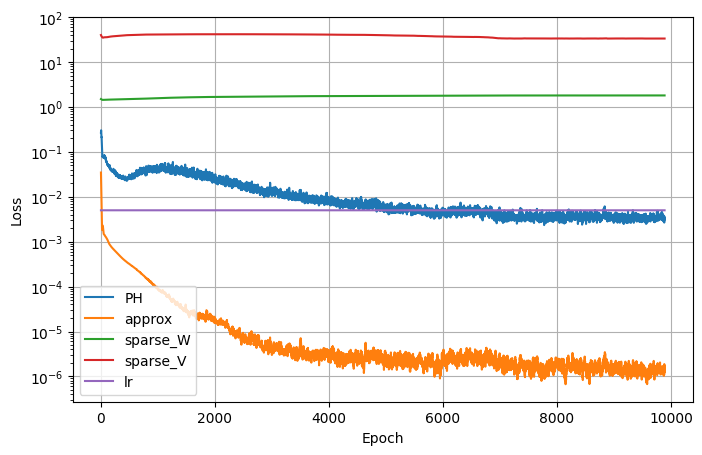

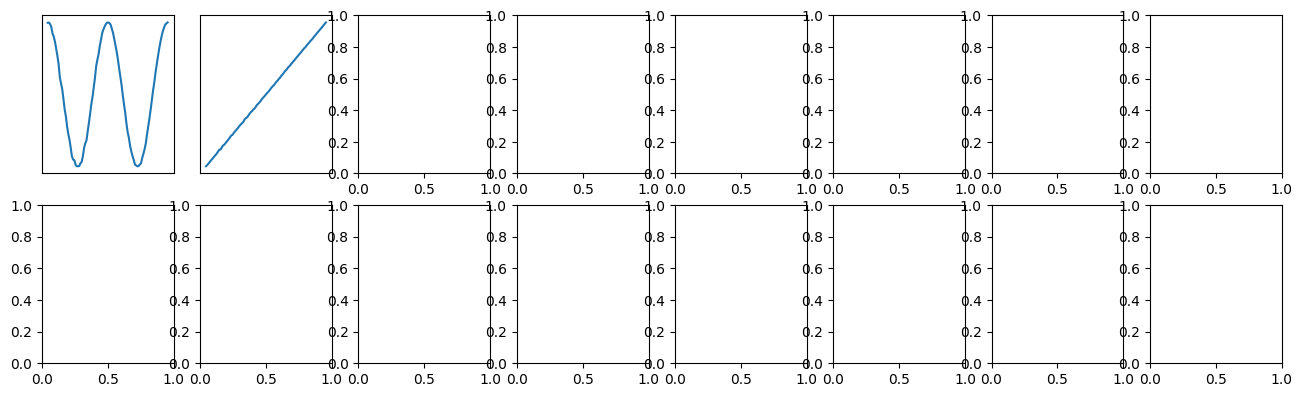

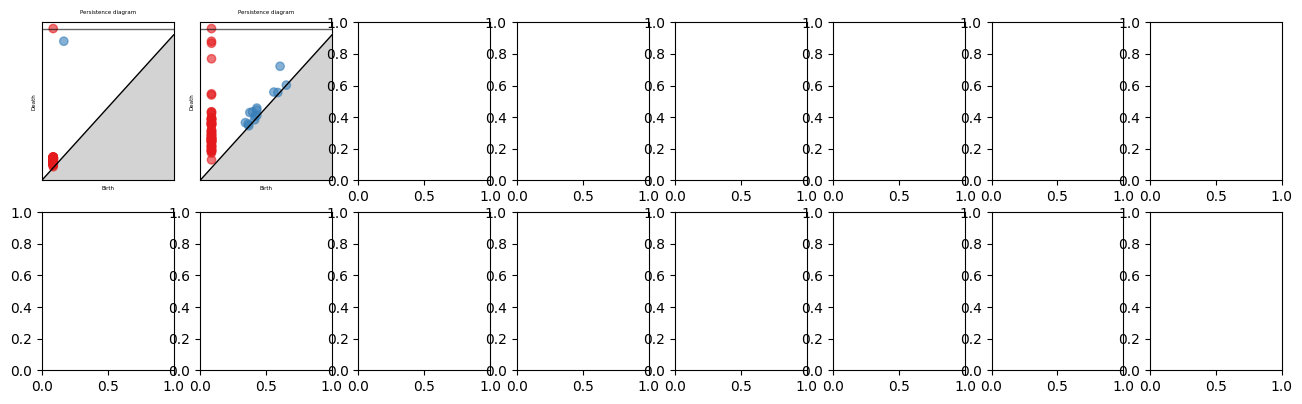

target L1/L2 ratio 0


In [204]:
# fit
lr = 0.005 # learning rate for gradient descent  (Adam: 0.1, SGD: 5)
target_sparsity = None # set to None, if you are not using
epsilon = 1e-10 # for numerical stability
PHmode = "V" # T or V construction
superlevel = True

## specify target PH (or set to None for sparsity)
target_PH = [torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False),torch.tensor([[]], dtype=torch.float, device=device, requires_grad=False)]
target_score = [0.95,0.9,0.88,0.0]
target_score = [1.0, 0.0, 1.0]

gd_iter = 1 # gradient descent update per iteration
mu_iter = 0 # multiplicative update per iteration
W_iter = 0 # W update per multiplicative update iteration
start_epoch_sparsify =0 # from this epoch, start sprase_opt
start_epoch_topological=0 # from this epoch, start loss_PH optimisation
show_plots = ["loss","basis","PH"] # ["loss","basis","PH"]

lambda_apx = 1.0 # (we do not have to use for mu) reconstruction loss in gradient descent
lambda_spa_V = 0.0 # (we do not have to use for mu)
lambda_spa_W = 0.0 # (we do not have to use for mu)
lambda_top = 0.001 # 0.1 # top-NMF   # around 0.001
weight_decay = 0.0

lambda_tv = 0.0 # 0.1


init_optimizer = True

normalise = False


M = 4
tau = int(len(t)/(2*(M+1)))
## filtration
rips_complex = VietorisRipsComplex(dim=1, p=2)
embedder = TimeDelayEmbeddingTorch(dim=M+1, delay=tau)


##
n_row, n_col = 2 , 8 # display
n_iterations = 10000
PH_dims = [1] # which dim to look at in PH
tol = 1e-4 # early stopping
tol_count = 50000 # early stopping
disp_interval = 10

loss_fn = torch.nn.MSELoss() # approximation error
# loss_fn = torch.nn.HuberLoss() # approximation error



##
X = torch.as_tensor(X.reshape(n_samples,-1), dtype=torch.float, device=device)
W = torch.tensor(W, dtype=torch.float, device=device, requires_grad=True)
V = torch.tensor(V, dtype=torch.float, device=device, requires_grad=True)
Vns = []
if normalise:
    with torch.no_grad():
        W /= (torch.norm(W, p=1, dim=1, keepdim=True)+epsilon)



## initialise optimiser
if init_optimizer:
    opt = optim.AdamW([W, V], lr=lr, weight_decay=weight_decay) # SGD, Adam, AdamW(weight decay for sparsity), or NAdam?
    # opt = optim.Adam([W, V], lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.9, patience=10000)



## optimisation iteration
progress = tqdm(range(n_iterations))
prev_loss = np.inf
count = 0
losses = {"PH":[], "approx":[], "sparse_W":[], "sparse_V":[], "lr":[]}

if target_sparsity is not None and target_sparsity > 0:
    target_L1 = np.sqrt(V.shape[1]) - target_sparsity * (np.sqrt(V.shape[1]) - 1)
else:
    target_L1 = 0

# prepare figures
if "loss" in show_plots:
    fig_L,axs_L = plt.subplots(1,1,figsize=(8,5))
    disp_L = display(fig_L,display_id=True)
if "basis" in show_plots:
    fig_V,axs_V = plt.subplots(n_row,n_col, figsize=(2. * n_col, 2.26 * n_row))
    disp_V = display(fig_V,display_id=True)
if "PH" in show_plots:
    fig_P,axs_P = plt.subplots(n_row,n_col, figsize=(2. * n_col, 2.26 * n_row))
    disp_P = display(fig_P,display_id=True)



def total_variation(v):
    return ((v[1:] - v[:-1])**2).sum()


    

## main iteration
for epoch in progress:
    # multiplicative update
    with torch.no_grad():
        for _ in range(mu_iter):
            #update V
            if target_sparsity is None or epoch<start_epoch_sparsify:
                W_TX = W.T @ X
                W_TWV = W.T @ W @ V + epsilon
                V *= W_TX / W_TWV
            else:
                update_V(X, W, V, target_L1) # update "V" with target sparsity

            #update W
            for _ in range(W_iter):
                XV_T = X @ V.T
                WVV_T = W @ V @ V.T + epsilon
                W *= XV_T / WVV_T

    # gradient descent update
    for _ in range(gd_iter):
        # compute PD of rows of V
        loss_PH=torch.tensor(0., device=device)
        if target_PH is None:
            loss_PH -= n_components
        loss_spa_V=torch.tensor(0., device=device)
        loss_spa_W=torch.tensor(0., device=device)
        sp_score=torch.tensor(0., device=device)
        loss_tv_V = torch.tensor(0., device=device)
        # for j in range(n_components):
        for j in range(n_components-1):
            v=V[j]
            # PH sparsity
            if lambda_top>0:
                
                point_cloud = embedder(v)
                point_cloud = center_point_cloud_torch(point_cloud)
                diags = rips_complex(point_cloud)
                if target_score is None:
                    # PH sparsity
                    PH = torch.cat([diags[dim].diagram for dim in PH_dims])
                    pers1 = torch.diff(PH, dim=1).reshape(-1)                    
                    l1sq = pers1.sum()**2
                    l2sq = pers1.pow(2).sum()
                    loss_PH += (l1sq/(l2sq+epsilon))
                else:
                    PH = torch.cat([diags[dim].diagram for dim in PH_dims])
                    pers1 = torch.diff(PH, dim=1).reshape(-1)
                    if len(pers1) > 0:
                        periodicity_score = max(pers1) / np.sqrt(3)
    
                    else:
                        periodicity_score = 0
                    
                    for dim in PH_dims:
                        if dim==0:
                            remove_longest_D1=True
                        else:
                            remove_longest_D1=False    
                        loss_PH += (periodicity_score - target_score[j])**2

            loss_tv_V += total_variation(v)
            
            # sparsity
            if target_sparsity is not None:
                loss_spa_V += (sparsity_score(v)-target_sparsity)**2
            else:
                #loss_spa += (1-sparsity_score(v))
                loss_spa_V += (v.abs().sum())**2/(v**2).sum()
            sp_score += sparsity_score(v)

        
        # loss_spa_W = (W.abs().sum())**2/(W**2).sum()  
        # row-wise
        # for j in range(n_samples):
        #     w=W[j]
        #     loss_spa_W += (w.abs().sum())**2/(w**2).sum()

        loss_spa_W = torch.sum(torch.sum(torch.abs(W), dim=1)**2/torch.sum(W**2, dim=1))    

        loss_spa_V /= n_components
        loss_spa_W /= n_components
        loss_PH /= n_components
        sp_score /= n_components
        loss_apx = loss_fn(torch.mm(W, V),X)
    
        # gradient descent
        loss = lambda_top * loss_PH + lambda_spa_V * loss_spa_V + lambda_spa_W * loss_spa_W +  lambda_apx * loss_apx + lambda_tv * loss_tv_V
        opt.zero_grad()
        loss.backward()
        #vv = V.clone().detach()
        opt.step()
        scheduler.step(loss)
        losses["PH"].append(loss_PH.item())
        losses["approx"].append(loss_apx.item())
        losses["sparse_V"].append(loss_spa_V.item())
        losses["sparse_W"].append(loss_spa_W.item())
        losses["lr"].append(scheduler.get_last_lr()[0])

    # Enforce nonnegativity by clamping
    with torch.no_grad():
        V.clamp_(min=0)
        W.clamp_(min=0)
        if normalise:
            W /= (torch.norm(W, p=1, dim=1, keepdim=True)+epsilon)


    # display
    progress.set_postfix(loss=f'PH: {loss_PH.item():.08f},sparsity: {sp_score.item():.08f},approx: {loss_apx.item():.08f}')
    if epoch%disp_interval==0:
        Vns.append(V.detach().cpu().numpy().copy())
        #clear_output(wait=True)
        
        # for key in losses.keys():
        #     line[key].set_xdata(range(len(losses[key])))
        #     line[key].set_ydata(losses[key])
        if "loss" in show_plots:
            plot_loss(losses,ax=axs_L)
            disp_L.update(fig_L)
        if "basis" in show_plots:
            plot_gallery(Vns[-1].reshape(-1,*data_dims),title="basis",n_row=n_row, n_col = n_col, axs=axs_V)
            disp_V.update(fig_V)
        if "PH" in show_plots:
            plot_PD(Vns[-1].reshape(-1,*data_dims),n_row=n_row, n_col = n_col, M=M, tau=tau, axs=axs_P)
            disp_P.update(fig_P)
        #plt.show()
        #display(plt.gcf())
        disp_interval = int(1.2*disp_interval) # increase interval

    # early stopping
    current = lambda_top * loss_PH + lambda_spa_V * loss_spa_V + lambda_spa_W * loss_spa_W + loss_apx
    if (prev_loss-current)<tol:
      count += 1
      if count > tol_count:
        break
    else:
      prev_loss = current.item()
      count = 0

# check norm
plt.close('all')
print("target L1/L2 ratio",target_L1)
#print(np.linalg.norm(V.detach(),axis=1))

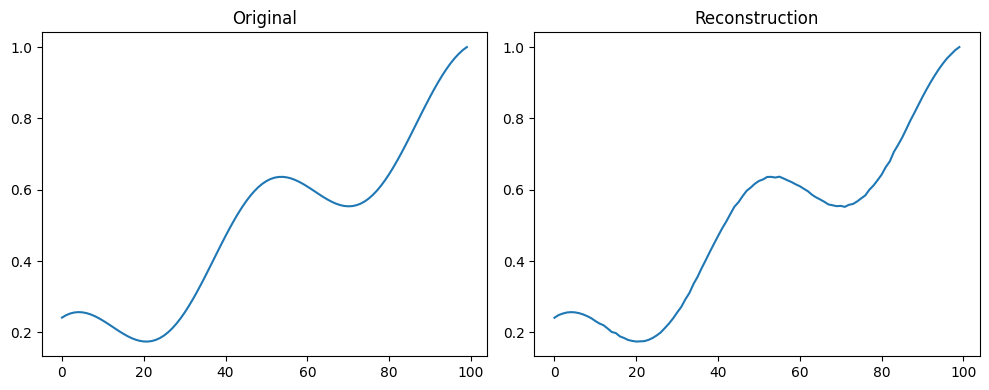

In [205]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(X[0])
axes[0].set_title("Original")

axes[1].plot((W @ V)[0].detach().numpy())
axes[1].set_title("Reconstruction")

plt.tight_layout()
plt.show()


array([<Axes: >, <Axes: >], dtype=object)

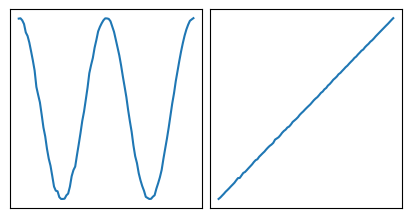

In [206]:
plot_gallery(Vns[-1].reshape(-1,*data_dims),n_row=1, n_col = 2)
# plt.savefig("time_series_4.pdf", dpi=600, bbox_inches='tight', pad_inches=0)

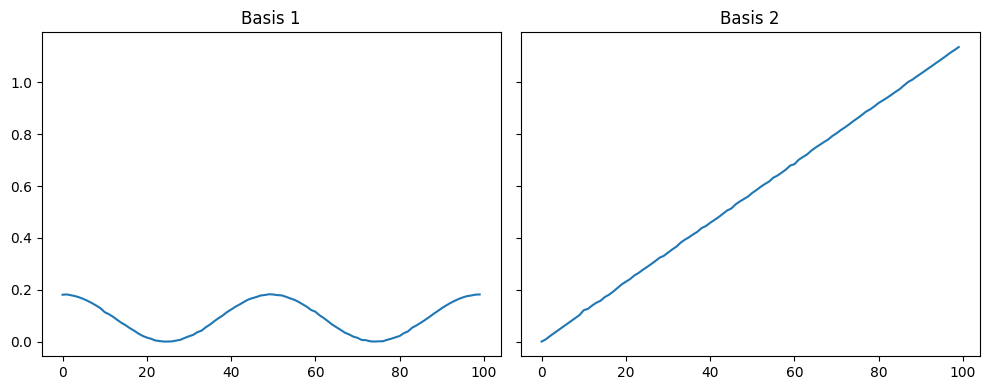

In [207]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(V[0].detach().numpy())
axes[0].set_title("Basis 1")

axes[1].plot(V[1].detach().numpy())
axes[1].set_title("Basis 2")

plt.tight_layout()
plt.show()


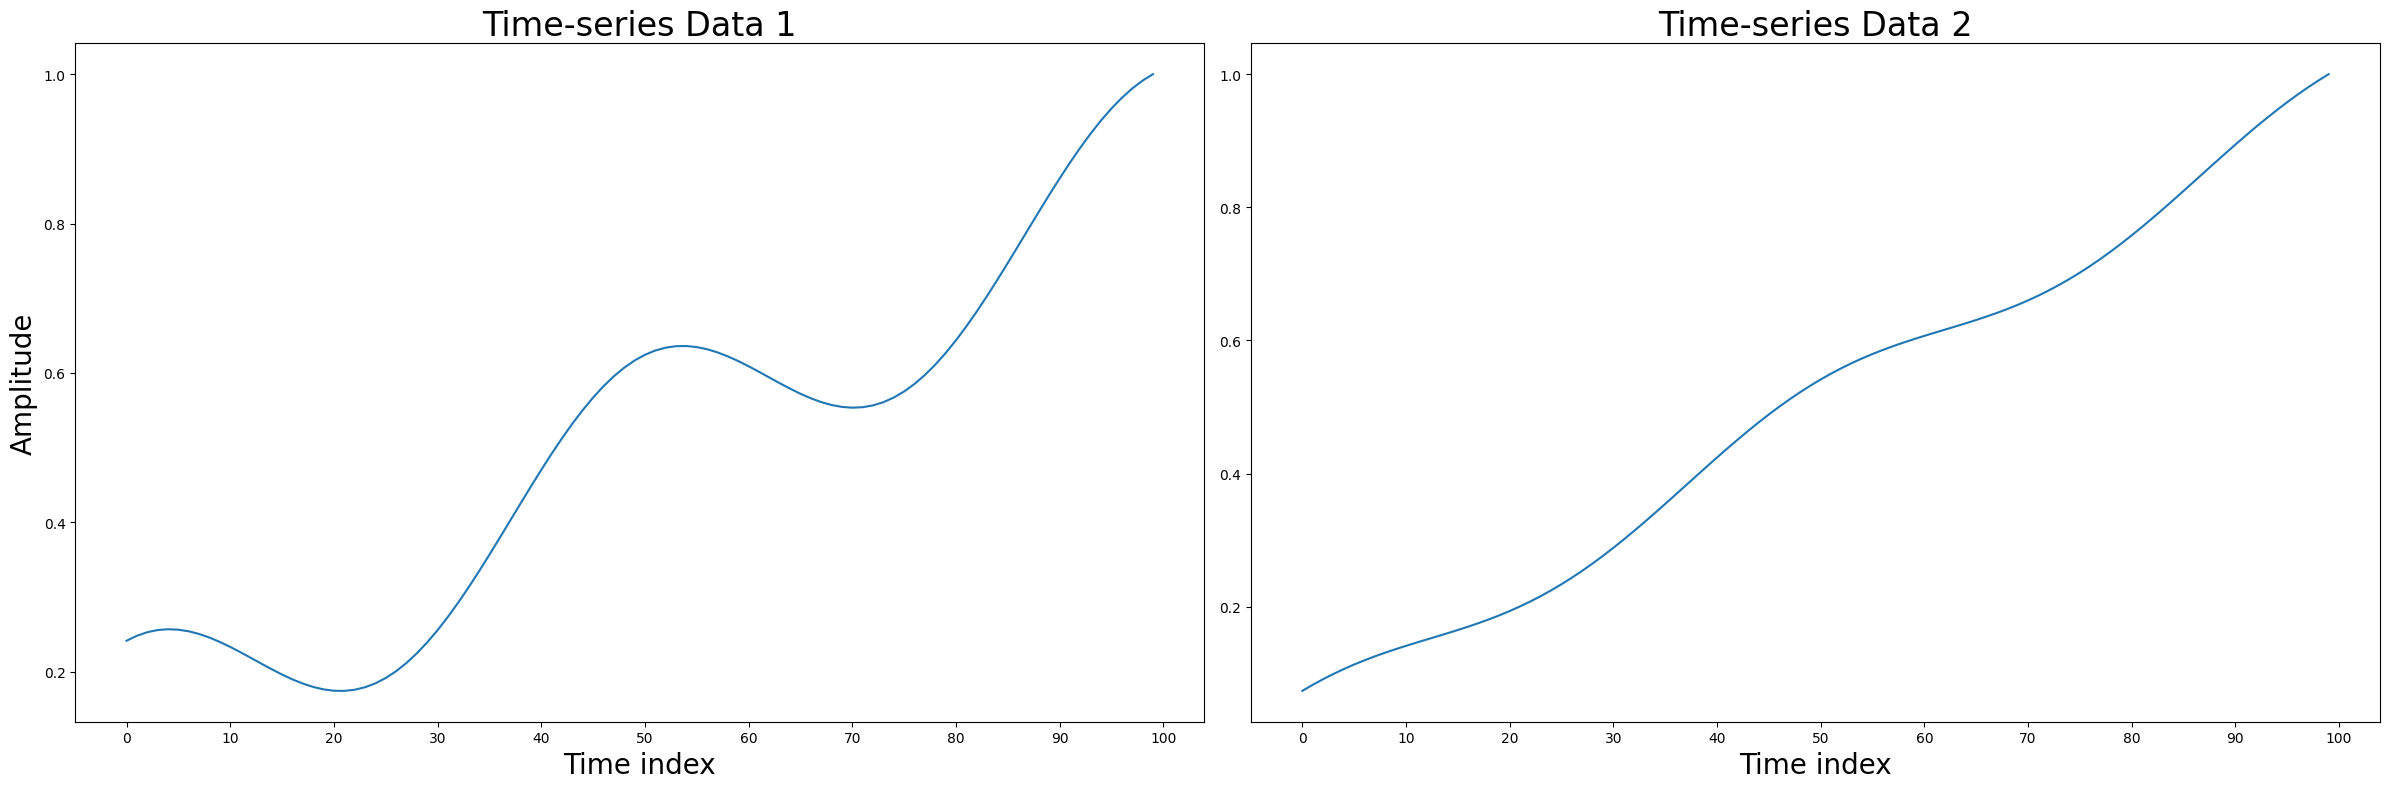

In [221]:
n = len(signals)
fig, axes = plt.subplots(1, n, figsize=(24, 8))  # ← 여기서 sharey
if n == 1:
    axes = [axes]

X_list = []
for i, (name, sig) in enumerate(signals.items()):
    sig = sig / np.max(sig)
    X_list.append(sig)

    ax = axes[i]
    idx = np.arange(len(sig))          # 0..99
    ax.plot(idx, sig)

    ax.set_title(f"Time-series Data {i+1}", fontsize=24)
    ax.set_xlabel("Time index", fontsize=20)
    if i == 0:
        ax.set_ylabel("Amplitude", fontsize=20)

    # x축: 0,10,20,...,90,99
    ticks = np.arange(0, len(sig)+1, 10)
    ax.set_xticks(ticks)

# 레이아웃
fig.tight_layout()
# fig.subplots_adjust(wspace=0.1)

# 저장 (PDF는 벡터라 dpi 영향 거의 없음)
fig.savefig("Example_5_13.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

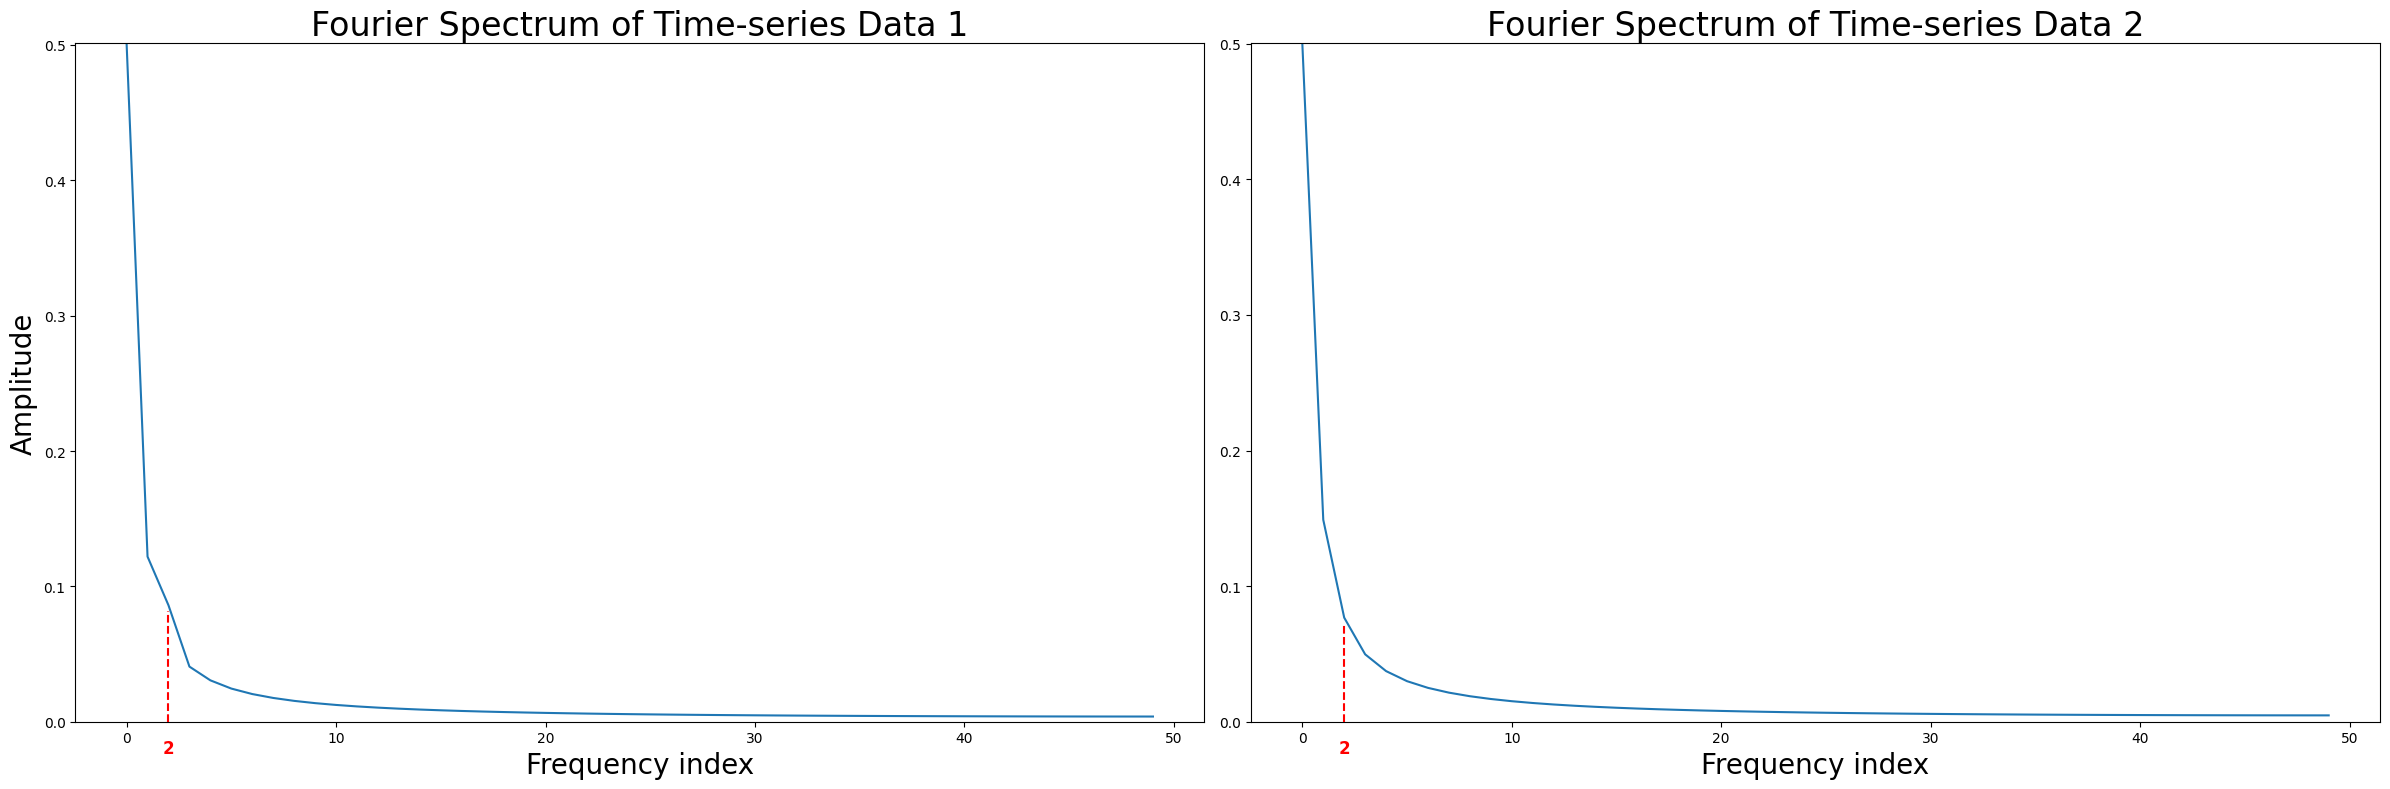

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

for i, ax in enumerate(axes):
    # Fourier transform
    spectrum = np.abs(np.fft.fft(X[i]))[:50] / 100
    ax.plot(spectrum, label=f"Series {i+1}")

    # 점선 위치와 끝점
    x0 = 2
    y0 = 0
    y1 = spectrum[x0] *0.95

    # y=0부터 정확히 x축까지 닿게 점선 그리기
    ax.plot([x0, x0], [y0, y1], 'r--', linewidth=1.5, zorder=3)

    # 숫자 라벨 (x축 위에 붙이기)
    ax.text(x0, -0.025 * spectrum.max(), "2", color='red',
            ha='center', va='top', fontsize=12, fontweight='bold')

    # 시각적 보정 — x축을 정확히 y=0에 맞추기
    ax.margins(y=0)
    ax.set_ylim(bottom=0)

    # 제목/레이블 설정
    ax.set_title(f"Fourier Spectrum of Time-series Data {i+1}", fontsize=24)
    ax.set_xlabel("Frequency index", size=20)
    if i == 0:
        ax.set_ylabel("Amplitude", size=20)

plt.tight_layout()
fig.savefig("Example_5_14.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

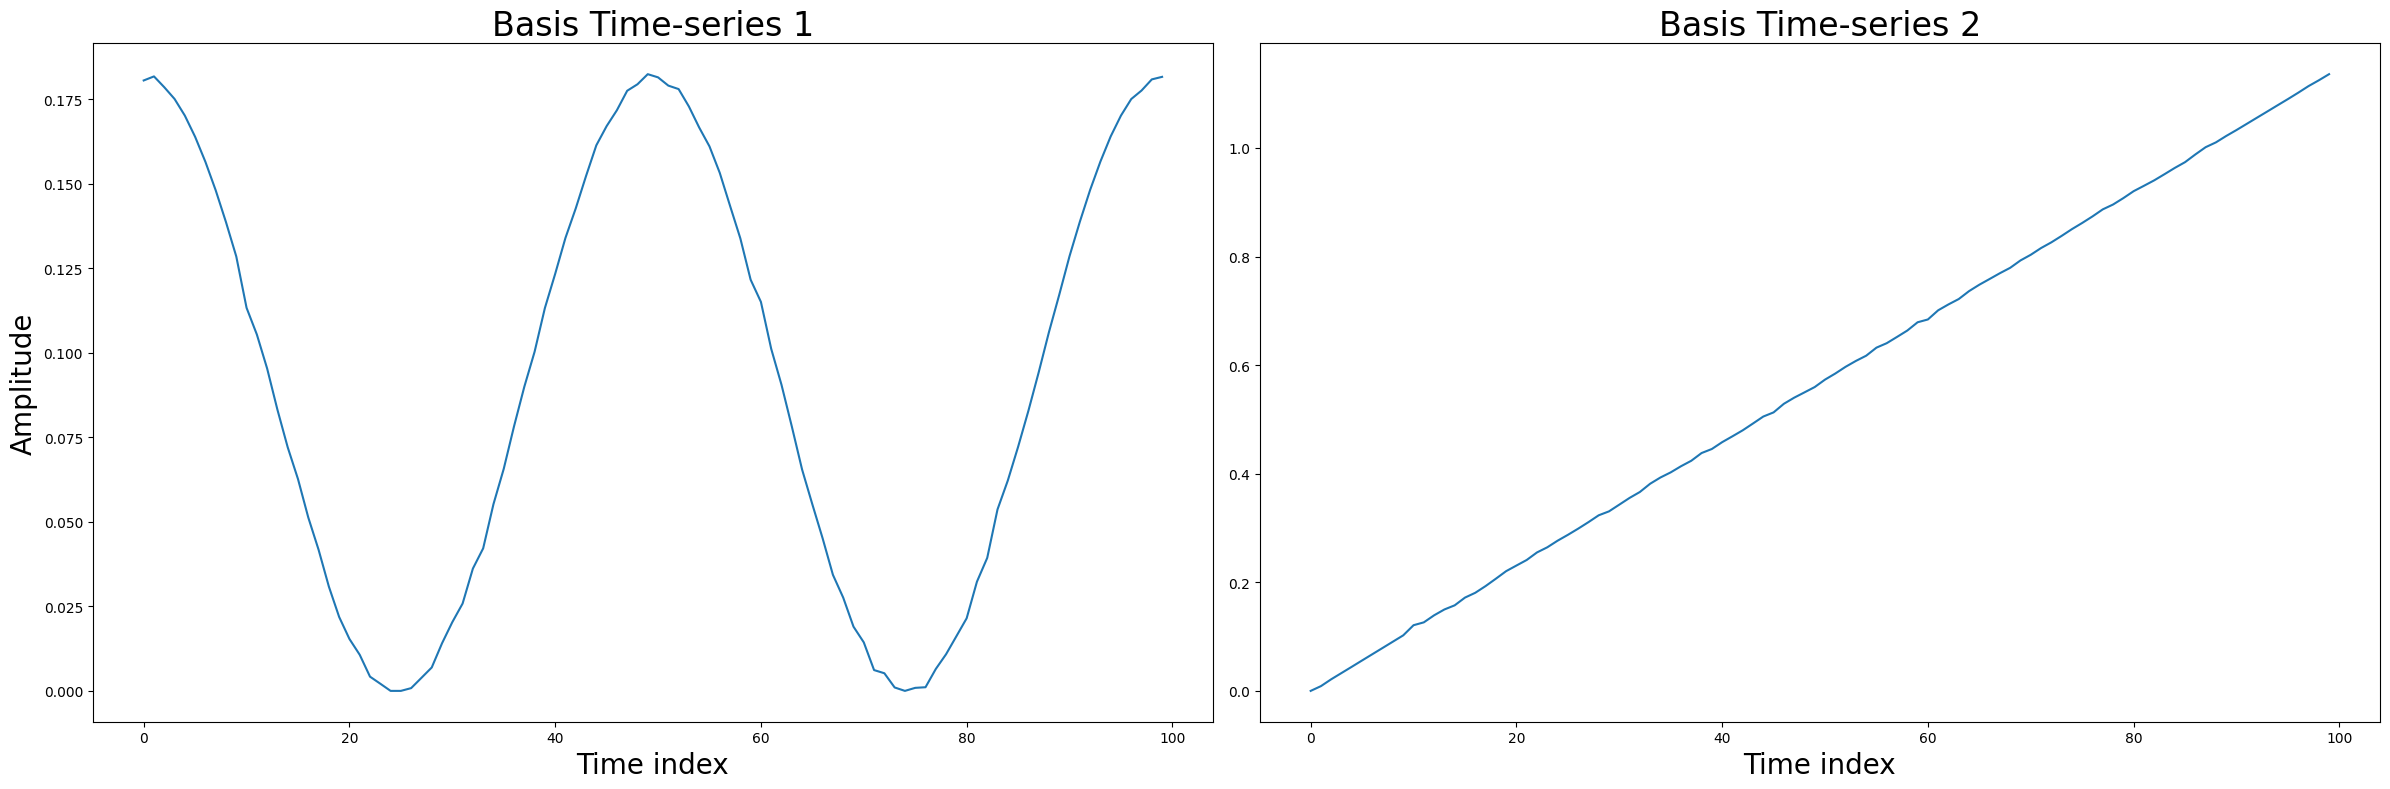

In [214]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

axes[0].plot(V[0].detach().numpy())
axes[0].set_title("Basis Time-series 1", size=24)
axes[0].set_ylabel("Amplitude", fontsize=20)
axes[0].set_xlabel("Time index", fontsize=20)

axes[1].plot(V[1].detach().numpy())
axes[1].set_title("Basis Time-series 2",size=24)
axes[1].set_xlabel("Time index", fontsize=20)

plt.tight_layout()
fig.savefig("Example_5_3.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

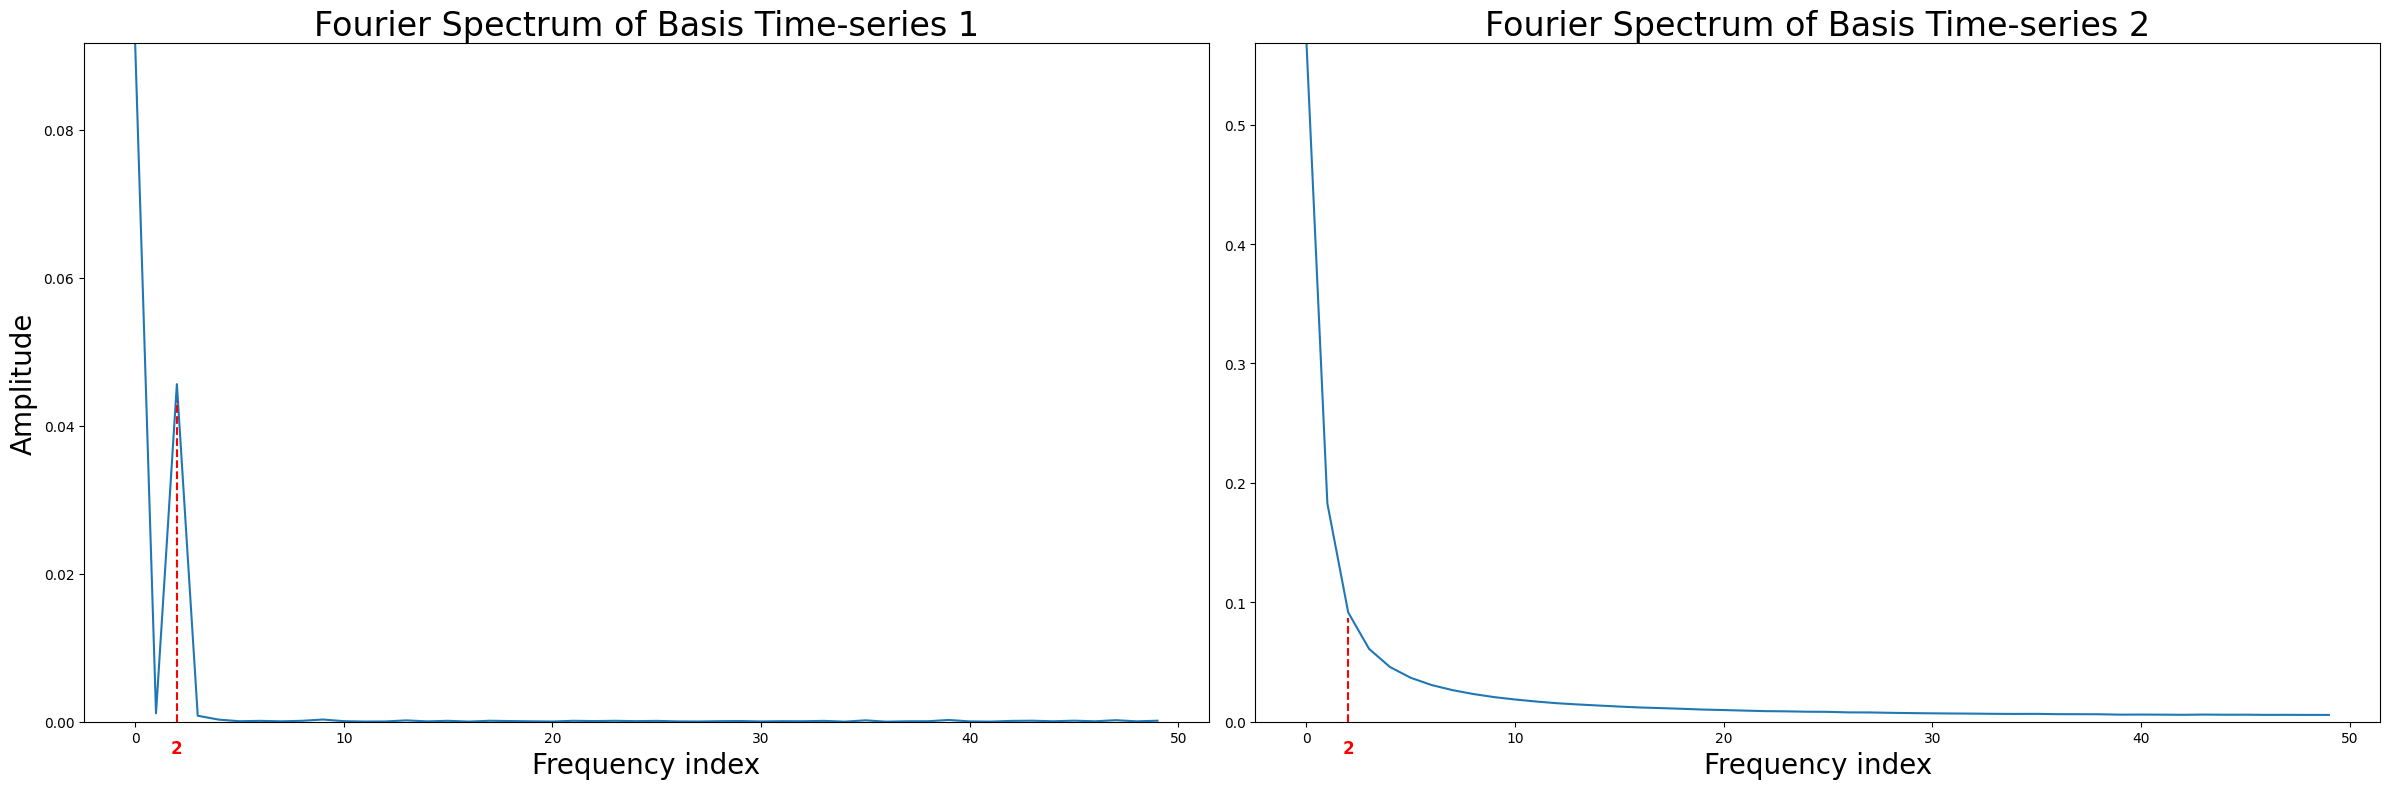

In [215]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

for i, ax in enumerate(axes):
    # Fourier transform
    spectrum = np.abs(np.fft.fft(V[i].detach().numpy()))[:50] / 100
    ax.plot(spectrum, label=f"Series {i+1}")

    # 점선 위치와 끝점
    x0 = 2
    y0 = 0
    y1 = spectrum[x0] *0.95

    # y=0부터 정확히 x축까지 닿게 점선 그리기
    ax.plot([x0, x0], [y0, y1], 'r--', linewidth=1.5, zorder=3)

    # 숫자 라벨 (x축 위에 붙이기)
    ax.text(x0, -0.025 * spectrum.max(), "2", color='red',
            ha='center', va='top', fontsize=12, fontweight='bold')

    # 시각적 보정 — x축을 정확히 y=0에 맞추기
    ax.margins(y=0)
    ax.set_ylim(bottom=0)

    # 제목/레이블 설정
    ax.set_title(f"Fourier Spectrum of Basis Time-series {i+1}", fontsize=24)
    ax.set_xlabel("Frequency index", size=20)
    if i == 0:
        ax.set_ylabel("Amplitude", size=20)

plt.tight_layout()
fig.savefig("Example_5_4.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

In [198]:
from ripser import ripser

def compute_sw1pers_score(signal, dim=30, tau=1):
    embedder = TimeDelayEmbedding(dim=dim, delay=tau)
    X = embedder(signal)
    X = center_point_cloud(X)


    diagrams = ripser(X, maxdim=1)['dgms']
    if len(diagrams[1]) > 0:
        max_persistence = np.max(diagrams[1][:, 1] - diagrams[1][:, 0])
        score = max_persistence / np.sqrt(3) # 이제 제대로 normalized
    else:
        score = 0
    return score

In [199]:
for i in range(n_components):
    print(compute_sw1pers_score(V[i].detach().numpy(), dim=M+1, tau=tau))

0.9107247455952423
0.001370870379872538


In [200]:
np.abs(np.fft.fft(V[0].detach().numpy()))[:50] / 100

array([9.64490862e-02, 1.32829945e-03, 4.81926489e-02, 1.00543225e-03,
       3.29220923e-04, 1.20140638e-04, 1.11841591e-04, 9.16926354e-05,
       3.83842240e-05, 2.69299783e-04, 3.48506503e-05, 1.30161808e-04,
       7.22428674e-05, 1.24533245e-04, 4.15682627e-05, 1.54495911e-04,
       2.28753790e-05, 3.26162574e-04, 4.34954343e-05, 8.06252652e-05,
       3.20596903e-05, 1.98515228e-04, 1.01769447e-04, 7.88655161e-05,
       6.96254778e-05, 6.68968307e-05, 1.30682863e-04, 1.55764674e-04,
       9.65111148e-05, 5.92622802e-05, 5.50311869e-05, 1.27303135e-04,
       5.39520308e-05, 9.50428302e-05, 7.94944261e-05, 6.86716572e-05,
       3.09077119e-05, 2.76964921e-04, 1.34921762e-04, 1.11654552e-05,
       3.57034714e-05, 2.01552404e-04, 9.57884429e-05, 8.99817590e-05,
       5.89831639e-05, 5.86964333e-05, 8.89872364e-05, 1.84623015e-04,
       1.25797004e-04, 2.23204883e-04])

In [201]:
np.abs(np.fft.fft(V[1].detach().numpy()))[:50] / 100

array([0.57177178, 0.18422728, 0.09212593, 0.06162304, 0.04618647,
       0.03697291, 0.03086683, 0.02637908, 0.02308671, 0.02084094,
       0.01871371, 0.01711913, 0.01583624, 0.01438424, 0.01360399,
       0.0129842 , 0.01197062, 0.0109677 , 0.01066703, 0.01037578,
       0.00987559, 0.00970947, 0.00911885, 0.00848991, 0.00845385,
       0.00818459, 0.00790506, 0.00773424, 0.00729016, 0.00748119,
       0.00711667, 0.00694063, 0.00710559, 0.00654879, 0.00657455,
       0.0066617 , 0.00634837, 0.00607271, 0.0060381 , 0.00623729,
       0.0060972 , 0.00628915, 0.00607681, 0.00582941, 0.00581588,
       0.0057638 , 0.00571882, 0.00569736, 0.00579049, 0.00602715])

In [161]:
V

tensor([[0.0473, 0.0480, 0.0496, 0.0496, 0.0504, 0.0497, 0.0497, 0.0487, 0.0480,
         0.0467, 0.0455, 0.0440, 0.0427, 0.0411, 0.0397, 0.0382, 0.0371, 0.0358,
         0.0352, 0.0343, 0.0342, 0.0339, 0.0345, 0.0348, 0.0361, 0.0373, 0.0392,
         0.0413, 0.0438, 0.0468, 0.0498, 0.0534, 0.0571, 0.0611, 0.0653, 0.0695,
         0.0741, 0.0784, 0.0830, 0.0873, 0.0918, 0.0959, 0.0999, 0.1041, 0.1068,
         0.1112, 0.1129, 0.1167, 0.1179, 0.1207, 0.1213, 0.1233, 0.1232, 0.1244,
         0.1236, 0.1242, 0.1228, 0.1227, 0.1210, 0.1204, 0.1185, 0.1177, 0.1155,
         0.1148, 0.1125, 0.1120, 0.1100, 0.1099, 0.1082, 0.1087, 0.1076, 0.1085,
         0.1084, 0.1096, 0.1106, 0.1122, 0.1142, 0.1165, 0.1193, 0.1222, 0.1257,
         0.1291, 0.1331, 0.1371, 0.1414, 0.1458, 0.1502, 0.1547, 0.1591, 0.1636,
         0.1679, 0.1719, 0.1759, 0.1796, 0.1829, 0.1861, 0.1889, 0.1913, 0.1934,
         0.1950],
        [0.0000, 0.0009, 0.0032, 0.0044, 0.0069, 0.0082, 0.0106, 0.0121, 0.0143,
         0